# Random Forest Hyperparameter Tuning

Uses 5-fold grouped cross-validation to tune:

- Number of trees (`n_estimators`)
- Maximum tree depth (`max_depth`)
- Minimum samples split (`min_samples_split`)
- Maximum features considered at each split (`max_features`)

Metric optimised: mean CV ROC-AUC

## 1. Imports & reproducibility

In [1]:
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')

SEED = 42

np.random.seed(SEED)
random.seed(SEED)

## 2. Load & preprocess data

In [2]:
# load
df = pd.read_csv(
    "/content/drive/MyDrive/Machine_Learning_Project/ML_notebooks/pd_speech_features.csv",
    skiprows=1
)

# split variables
X = df.drop(columns=["class", "id"])
y = df["class"]
groups = df["id"]

# grouped train/test split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

train_groups = groups.iloc[train_idx].copy()

# remove highly correlated features using train set only
corr = X_train.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.96)]

X_train = X_train.drop(columns=to_drop)
X_test = X_test.drop(columns=to_drop)

print(f"Features after correlation filter: {X_train.shape[1]}")

# mutual information feature selection
N_FEATURES = 100

selector = SelectKBest(mutual_info_classif, k=N_FEATURES)
selector.fit(X_train, y_train)

selected_cols = X_train.columns[selector.get_support()]

X_train = pd.DataFrame(
    selector.transform(X_train),
    columns=selected_cols,
    index=X_train.index
)

X_test = pd.DataFrame(
    selector.transform(X_test),
    columns=selected_cols,
    index=X_test.index
)

print(f"Features after MI selection: {X_train.shape[1]}")

# grouped cross-validation
group_kfold = GroupKFold(n_splits=5)

X_arr = X_train.values
y_arr = y_train.values
g_arr = train_groups.values

Features after correlation filter: 539
Features after MI selection: 100


## 3. Hyperparameter tuning — 5-fold grouped CV

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_score
import pandas as pd

print("=== Random Forest Grid Search with GroupKFold CV ===")

results = []

group_kfold = GroupKFold(n_splits=5)
train_groups = groups.iloc[train_idx]

for n in [100, 200, 300]:
    for d in [5, 10, 20]:

        rf = RandomForestClassifier(
            n_estimators=n,
            max_depth=d,
            random_state=42,
            n_jobs=-1
        )

        roc_scores = cross_val_score(
            rf,
            X_train,
            y_train,
            cv=group_kfold,
            groups=train_groups,
            scoring="roc_auc",
            n_jobs=-1
        )

        acc_scores = cross_val_score(
            rf,
            X_train,
            y_train,
            cv=group_kfold,
            groups=train_groups,
            scoring="accuracy",
            n_jobs=-1
        )

        results.append({
            "n_estimators": n,
            "max_depth": d,
            "cv_roc_auc_mean": roc_scores.mean(),
            "cv_roc_auc_std": roc_scores.std(),
            "cv_accuracy_mean": acc_scores.mean(),
            "cv_accuracy_std": acc_scores.std()
        })

results_df = pd.DataFrame(results)

best_results = results_df.sort_values(by="cv_roc_auc_mean", ascending=False)

best_params = best_results.iloc[0]

=== Random Forest Grid Search with GroupKFold CV ===


## 4. Best parameters

In [4]:
print("=== Best Random Forest Parameters ===")
print(f"n_estimators : {best_params['n_estimators']}")
print(f"max_depth    : {best_params['max_depth']}")
print(f"CV ROC-AUC   : {best_params['cv_roc_auc_mean']:.4f}")

=== Best Random Forest Parameters ===
n_estimators : 300.0
max_depth    : 20.0
CV ROC-AUC   : 0.8315


## 5. Results table

In [5]:
results_df = results_df.sort_values(
    by="cv_roc_auc_mean",
    ascending=False
).reset_index(drop=True)

print("Top 10 Random Forest combinations:")
display(results_df.head(10))

Top 10 Random Forest combinations:


,n_estimators,max_depth,cv_roc_auc_mean,cv_roc_auc_std,cv_accuracy_mean,cv_accuracy_std
0,300,20,0.831490,0.098189,0.829146,0.065825
1,200,20,0.830710,0.098585,0.822520,0.064315
2,100,20,0.824838,0.104558,0.832520,0.063922
3,300,10,0.824363,0.102405,0.829146,0.066246
4,200,10,0.821592,0.102946,0.832520,0.067925
5,300,5,0.821185,0.108908,0.824187,0.061148
6,200,5,0.818405,0.109752,0.820935,0.064321
7,100,10,0.814051,0.107723,0.824309,0.067884
8,100,5,0.809582,0.106816,0.824309,0.061666


## 6. Visualise the search

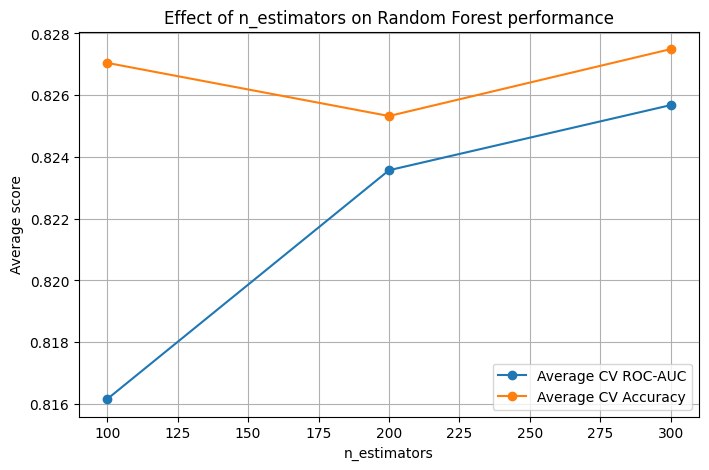

In [6]:
n_summary = results_df.groupby("n_estimators")[["cv_roc_auc_mean", "cv_accuracy_mean"]].mean().reset_index()

plt.figure(figsize=(8,5))
plt.plot(n_summary["n_estimators"], n_summary["cv_roc_auc_mean"], marker="o", label="Average CV ROC-AUC")
plt.plot(n_summary["n_estimators"], n_summary["cv_accuracy_mean"], marker="o", label="Average CV Accuracy")

plt.xlabel("n_estimators")
plt.ylabel("Average score")
plt.title("Effect of n_estimators on Random Forest performance")
plt.legend()
plt.grid()
plt.show()

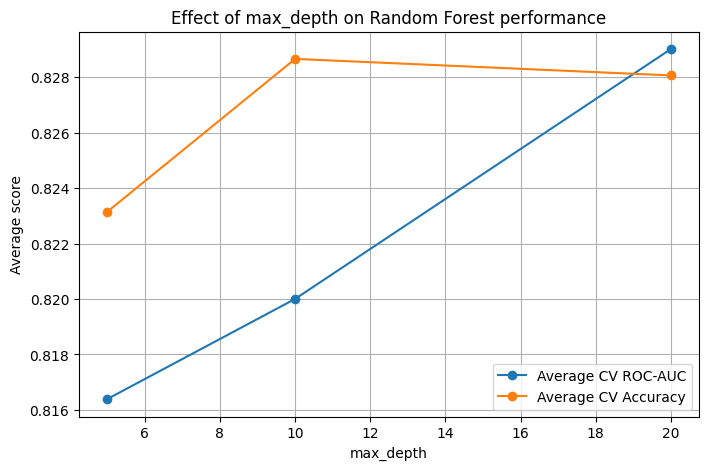

In [7]:
depth_summary = results_df.groupby("max_depth")[["cv_roc_auc_mean", "cv_accuracy_mean"]].mean().reset_index()

plt.figure(figsize=(8,5))
plt.plot(depth_summary["max_depth"], depth_summary["cv_roc_auc_mean"], marker="o", label="Average CV ROC-AUC")
plt.plot(depth_summary["max_depth"], depth_summary["cv_accuracy_mean"], marker="o", label="Average CV Accuracy")

plt.xlabel("max_depth")
plt.ylabel("Average score")
plt.title("Effect of max_depth on Random Forest performance")
plt.legend()
plt.grid()
plt.show()

## 7. Retrain best model on full training set

In [8]:
best_rf = RandomForestClassifier(
    n_estimators=int(best_params["n_estimators"]),
    max_depth=int(best_params["max_depth"]),
    random_state=SEED,
    n_jobs=-1
)

best_rf.fit(X_train, y_train)

print("Final Random Forest model trained.")

Final Random Forest model trained.


## 8. Test-set evaluation


=== Random Forest Test Performance, threshold = 0.50 ===
              precision    recall  f1-score   support

           0       0.81      0.40      0.54        42
           1       0.81      0.96      0.88       111

    accuracy                           0.81       153
   macro avg       0.81      0.68      0.71       153
weighted avg       0.81      0.81      0.79       153

Test ROC-AUC: 0.9279


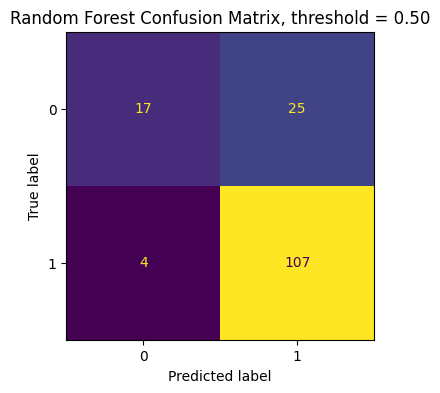

In [9]:
proba_rf = best_rf.predict_proba(X_test)[:, 1]
pred_rf = (proba_rf >= 0.5).astype(int)

print("=== Random Forest Test Performance, threshold = 0.50 ===")
print(classification_report(y_test, pred_rf))
print(f"Test ROC-AUC: {roc_auc_score(y_test, proba_rf):.4f}")

cm = confusion_matrix(y_test, pred_rf)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]).plot(
    ax=ax,
    colorbar=False,
    values_format="d"
)
ax.set_title("Random Forest Confusion Matrix, threshold = 0.50")
plt.show()

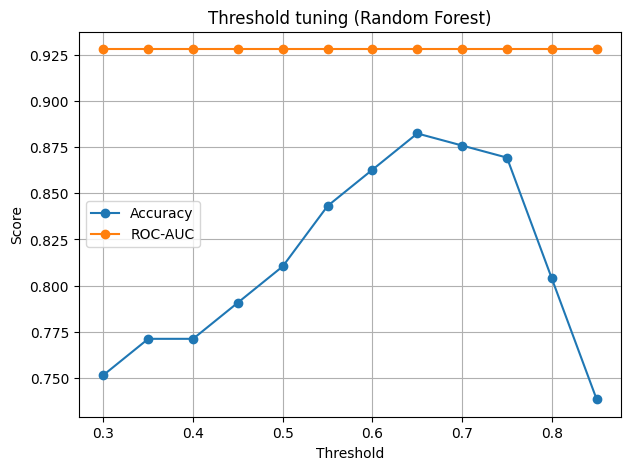

In [10]:
## Threshold tuning

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score

thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6,
              0.65, 0.7, 0.75, 0.8, 0.85]

accuracies = []
roc_aucs = []

# probabilities from Random Forest
proba_rf = best_rf.predict_proba(X_test)[:, 1]

# ROC-AUC is independent of threshold
roc_auc = roc_auc_score(y_test, proba_rf)

for t in thresholds:
    pred_t = (proba_rf >= t).astype(int)

    acc = accuracy_score(y_test, pred_t)

    accuracies.append(acc)
    roc_aucs.append(roc_auc)

plt.figure(figsize=(7,5))

plt.plot(thresholds, accuracies,
         marker='o',
         label="Accuracy")

plt.plot(thresholds, roc_aucs,
         marker='o',
         label="ROC-AUC")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold tuning (Random Forest)")
plt.legend()
plt.grid()

plt.show()

## 9. Feature importance

std_delta_delta_log_energy     0.038340
std_delta_log_energy           0.033685
std_7th_delta_delta            0.030311
mean_MFCC_2nd_coef             0.023482
std_6th_delta_delta            0.020522
tqwt_energy_dec_27             0.020290
tqwt_entropy_log_dec_27        0.020123
tqwt_TKEO_mean_dec_12          0.019650
tqwt_entropy_log_dec_12        0.018583
tqwt_TKEO_std_dec_12           0.018433
tqwt_kurtosisValue_dec_26      0.018212
numPulses                      0.017993
tqwt_energy_dec_26             0.017887
std_9th_delta_delta            0.017650
tqwt_entropy_shannon_dec_35    0.016062
tqwt_entropy_shannon_dec_36    0.015874
tqwt_kurtosisValue_dec_27      0.015260
tqwt_entropy_shannon_dec_12    0.015099
std_6th_delta                  0.014907
std_8th_delta_delta            0.013705
dtype: float64


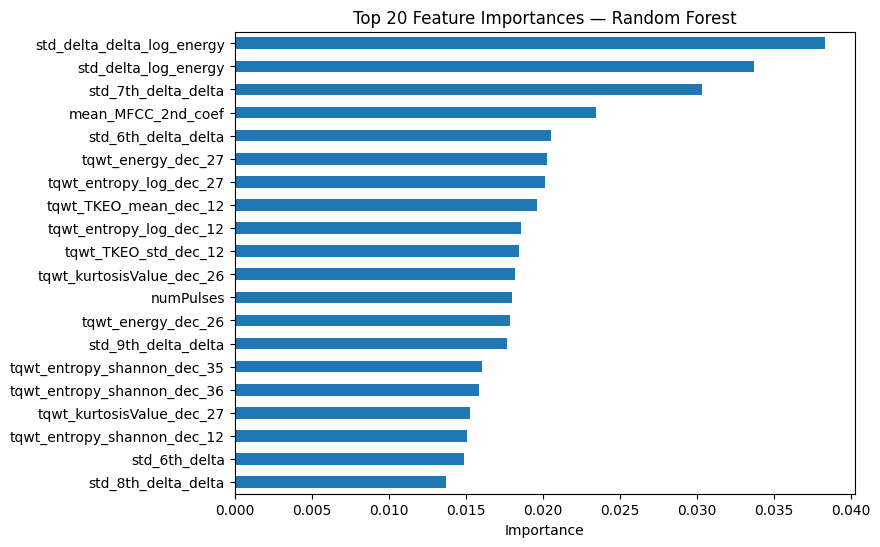

In [11]:
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
top20 = importances.sort_values(ascending=False).head(20)

print(top20)

top20.sort_values().plot(kind="barh", figsize=(8,6))

plt.xlabel("Importance")
plt.title("Top 20 Feature Importances — Random Forest")

plt.show()

# Random Forest Model Summary

- We trained a Random Forest classifier using a grouped train/test split and GroupKFold cross-validation to avoid patient leakage and ensure robust evaluation across patients.

- The main hyperparameters tuned were:
  - **n_estimators** (number of trees)
  - **max_depth** (tree depth / model complexity)

- The best configuration was:
  - **n_estimators = 300**
  - **max_depth = 20**

- Increasing the number of trees and the maximum depth slightly improved the cross-validation ROC-AUC, suggesting that a larger ensemble with deeper trees captured more complex patterns in the speech features.

- The final model achieved:
  - **Test ROC-AUC ≈ 0.93**
  - **Best accuracy ≈ 0.88** (around threshold 0.65)

- The confusion matrix shows:
  - **Very high recall for Parkinson’s patients**
  - **Low specificity for healthy individuals**, meaning the model tends to produce false positives rather than false negatives.

- This behaviour is desirable for medical screening tasks, where missing a diseased patient is generally more problematic than incorrectly flagging a healthy patient.

- Threshold tuning showed that changing the classification threshold significantly affects accuracy and the balance between sensitivity and specificity, while ROC-AUC remains constant because it is threshold-independent.

- Feature importance analysis indicates that multiple speech features contribute to the prediction, rather than a single dominant biomarker.

- Overall, the Random Forest model achieved strong predictive performance and generalized well on unseen patients while remaining relatively interpretable through feature importance analysis.

# Bagging Hyperparameter Tuning

Uses 5-fold grouped cross-validation to tune:

- Number of base estimators (`n_estimators`)
- Maximum depth of each decision tree (`max_depth`)

Each Bagging model uses several decision trees trained on bootstrap samples of the training data.

Metric optimised: mean CV ROC-AUC

## 1. Imports

In [14]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GroupKFold, cross_val_score
import pandas as pd

## 2. Hyperparameter tuning — 5-fold grouped CV

In [18]:
print("=== Bagging Grid Search with GroupKFold CV ===")

results_bagging = []

group_kfold = GroupKFold(n_splits=5)
train_groups = groups.iloc[train_idx]

for n in [50, 100, 200]:
    for d in [5, 10, 20]:

        base_tree = DecisionTreeClassifier(
            max_depth=d,
            random_state=42
        )

        bag = BaggingClassifier(
            estimator=base_tree,
            n_estimators=n,
            random_state=42,
            n_jobs=-1
        )

        roc_scores = cross_val_score(
            bag,
            X_train,
            y_train,
            cv=group_kfold,
            groups=train_groups,
            scoring="roc_auc",
            n_jobs=-1
        )

        acc_scores = cross_val_score(
            bag,
            X_train,
            y_train,
            cv=group_kfold,
            groups=train_groups,
            scoring="accuracy",
            n_jobs=-1
        )

        results_bagging.append({
            "n_estimators": n,
            "max_depth": d,
            "cv_roc_auc_mean": roc_scores.mean(),
            "cv_roc_auc_std": roc_scores.std(),
            "cv_accuracy_mean": acc_scores.mean(),
            "cv_accuracy_std": acc_scores.std()
        })

results_bagging_df = pd.DataFrame(results_bagging)

best_bagging_results = results_bagging_df.sort_values(by="cv_roc_auc_mean", ascending=False)

best_bagging_params = best_bagging_results.iloc[0]

=== Bagging Grid Search with GroupKFold CV ===


## 3. Best parameters

In [19]:
print("=== Best Bagging Parameters ===")

print(f"n_estimators : {int(best_bagging_params['n_estimators'])}")
print(f"max_depth    : {int(best_bagging_params['max_depth'])}")
print(f"CV ROC-AUC   : {best_bagging_params['cv_roc_auc_mean']:.4f}")

=== Best Bagging Parameters ===
n_estimators : 100
max_depth    : 10
CV ROC-AUC   : 0.8087


## 4. Results table

In [20]:
results_bagging_df = results_bagging_df.sort_values(
    by="cv_roc_auc_mean",
    ascending=False
).reset_index(drop=True)

print("Top 10 Bagging combinations:")

display(results_bagging_df.head(10))

Top 10 Bagging combinations:


,n_estimators,max_depth,cv_roc_auc_mean,cv_roc_auc_std,cv_accuracy_mean,cv_accuracy_std
0,100,10,0.808670,0.100226,0.806016,0.064501
1,200,5,0.806322,0.097556,0.812602,0.065934
2,50,10,0.806279,0.096197,0.807724,0.066204
3,200,10,0.804894,0.097472,0.815935,0.063043
4,100,5,0.803938,0.103680,0.815935,0.057994
5,200,20,0.801110,0.099451,0.822520,0.061217
6,100,20,0.800725,0.100604,0.815935,0.063043
7,50,20,0.790798,0.102628,0.810976,0.065157
8,50,5,0.790762,0.103026,0.814268,0.061099


## 5. Visualise the search

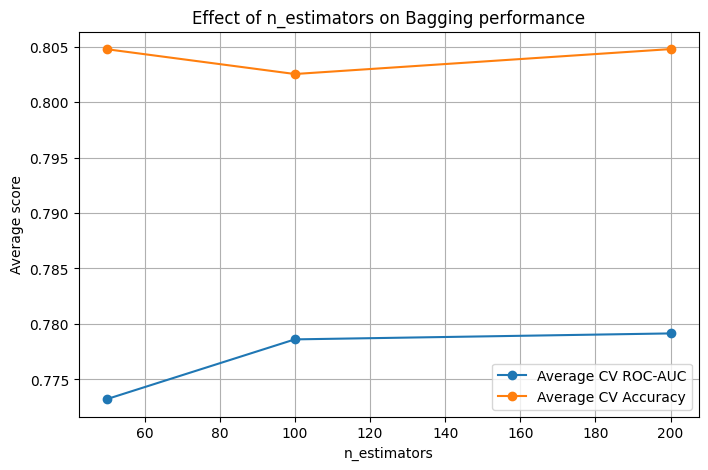

In [ ]:
import matplotlib.pyplot as plt

n_summary_bagging = results_bagging_df.groupby("n_estimators")[["cv_roc_auc_mean", "cv_accuracy_mean"]].mean().reset_index()

plt.figure(figsize=(8,5))
plt.plot(n_summary_bagging["n_estimators"], n_summary_bagging["cv_roc_auc_mean"], marker="o", label="Average CV ROC-AUC")
plt.plot(n_summary_bagging["n_estimators"], n_summary_bagging["cv_accuracy_mean"], marker="o", label="Average CV Accuracy")

plt.xlabel("n_estimators")
plt.ylabel("Average score")
plt.title("Effect of n_estimators on Bagging performance")
plt.legend()
plt.grid()
plt.show()

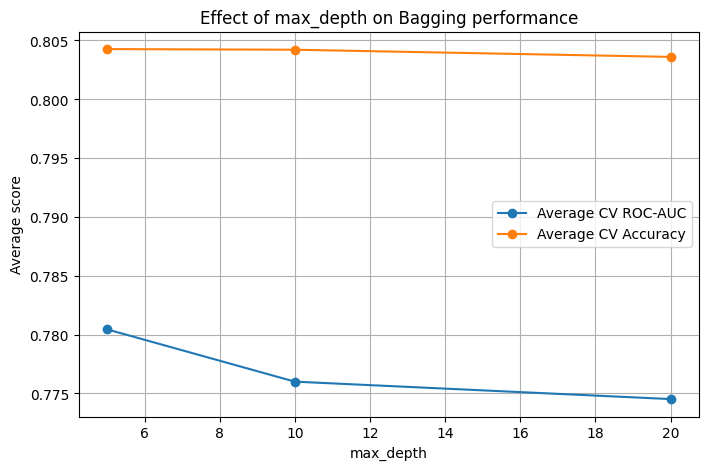

In [ ]:
depth_summary_bagging = results_bagging_df.groupby("max_depth")[["cv_roc_auc_mean", "cv_accuracy_mean"]].mean().reset_index()

plt.figure(figsize=(8,5))
plt.plot(depth_summary_bagging["max_depth"], depth_summary_bagging["cv_roc_auc_mean"], marker="o", label="Average CV ROC-AUC")
plt.plot(depth_summary_bagging["max_depth"], depth_summary_bagging["cv_accuracy_mean"], marker="o", label="Average CV Accuracy")

plt.xlabel("max_depth")
plt.ylabel("Average score")
plt.title("Effect of max_depth on Bagging performance")
plt.legend()
plt.grid()
plt.show()

## 6. Retrain best model on full training set

In [21]:
best_bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=int(best_bagging_params["max_depth"]),
        random_state=SEED
    ),
    n_estimators=int(best_bagging_params["n_estimators"]),
    random_state=SEED,
    n_jobs=-1
)

best_bagging.fit(X_train, y_train)

print("Final Bagging model trained.")

Final Bagging model trained.


## 7. Test-set evaluation

In [22]:
proba_bagging = best_bagging.predict_proba(X_test)[:, 1]
pred_bagging = (proba_bagging >= 0.5).astype(int)

print("=== Final Bagging Test Performance ===")

print(classification_report(y_test, pred_bagging))

print(f"ROC-AUC: {roc_auc_score(y_test, proba_bagging):.4f}")

=== Final Bagging Test Performance ===
              precision    recall  f1-score   support

           0       0.87      0.48      0.62        42
           1       0.83      0.97      0.90       111

    accuracy                           0.84       153
   macro avg       0.85      0.72      0.76       153
weighted avg       0.84      0.84      0.82       153

ROC-AUC: 0.9294


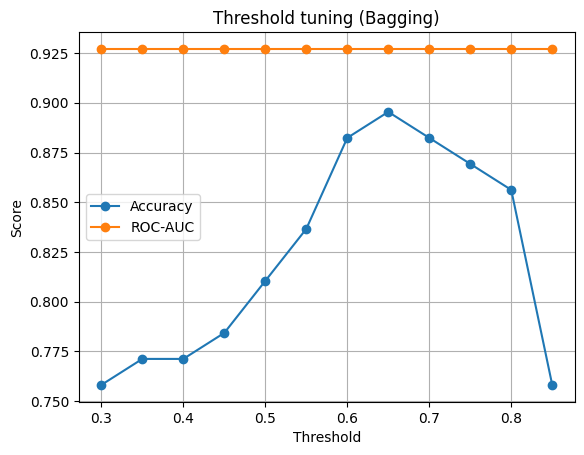

In [ ]:
### Threshold tuning

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score

thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85]

accuracies = []
roc_aucs = []

# ROC-AUC (constant)
roc_auc = roc_auc_score(y_test, proba_bagging)

for t in thresholds:
    pred_t = (proba_bagging >= t).astype(int)
    acc = accuracy_score(y_test, pred_t)

    accuracies.append(acc)
    roc_aucs.append(roc_auc)

plt.figure()
plt.plot(thresholds, accuracies, marker='o', label="Accuracy")
plt.plot(thresholds, roc_aucs, marker='o', label="ROC-AUC")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold tuning (Bagging)")
plt.legend()
plt.grid()
plt.show()

# SUMMARY: Comparison between Random Forest and Bagging

In [23]:
print("=== Model comparison on test set ===")

print(f"Random Forest ROC-AUC: {roc_auc_score(y_test, proba_rf):.4f}")
print(f"Bagging ROC-AUC:       {roc_auc_score(y_test, proba_bagging):.4f}")

rf_acc = ((proba_rf >= 0.5).astype(int) == y_test).mean()
bag_acc = ((proba_bagging >= 0.5).astype(int) == y_test).mean()

print(f"Random Forest Accuracy: {rf_acc:.4f}")
print(f"Bagging Accuracy:       {bag_acc:.4f}")

=== Model comparison on test set ===
Random Forest ROC-AUC: 0.9279
Bagging ROC-AUC:       0.9294
Random Forest Accuracy: 0.8105
Bagging Accuracy:       0.8366


# Comparison: Random Forest vs Bagging

- Both ensemble methods achieved strong predictive performance on the Parkinson’s speech dataset.

- Random Forest achieved:
  - **ROC-AUC ≈ 0.928**
  - **Accuracy ≈ 0.81**

- Bagging achieved:
  - **ROC-AUC ≈ 0.929**
  - **Accuracy ≈ 0.84**

- Bagging slightly outperformed Random Forest on this test split, particularly in overall accuracy.

- Both models achieved very high recall for Parkinson’s patients, meaning they successfully detected most diseased individuals.

- However, both models produced more false positives for healthy patients, reflecting a trade-off favoring sensitivity over specificity.

- Overall, the results show that ensemble tree-based methods are highly effective for Parkinson’s disease detection using speech features.